# ACDC Classification — Results Plots

Loads a JSON results file produced by `scripts/run_acdc_classification.py`
and generates all diagnostic plots.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import auc as sk_auc
from sklearn.metrics import roc_curve as sk_roc_curve
from sklearn.preprocessing import label_binarize

## Configuration

Set the path to the JSON results file below.

In [2]:
RESULTS_PATH = Path("../../results/classification/cinema_logreg.json")

with open(RESULTS_PATH) as f:
    results = json.load(f)

config = results["config"]
sweep = results["sweep_results"]
five_way = results["five_way"]
roc = results["roc_auc"]
binary = results["binary"]

MODEL_NAME = config["model_name"]
EVAL_MODE = config["eval_mode"]
PATHOLOGY_CLASSES = {"NOR": 0, "DCM": 1, "HCM": 2, "MINF": 3, "RV": 4}
PATHOLOGY_NAMES_LONG = {
    "NOR": "Normal",
    "DCM": "Dilated CM",
    "HCM": "Hypertrophic CM",
    "MINF": "MI",
    "RV": "RV Abnormality",
}
NUM_PATHOLOGIES = len(PATHOLOGY_CLASSES)

print(f"Loaded: {RESULTS_PATH.name}")
print(f"Backbone: {config['backbone']} ({MODEL_NAME})")
print(f"Eval mode: {EVAL_MODE}")
print(f"5-way Acc: {five_way['accuracy']:.4f}, Macro F1: {five_way['macro_f1']:.4f}")
print(f"Macro ROC AUC: {roc['macro_auc']:.4f}")

Loaded: cinema_logreg.json
Backbone: cinema (cinema_pretrained)
Eval mode: logreg
5-way Acc: 0.5800, Macro F1: 0.5768
Macro ROC AUC: 0.8130


## Hyperparameter Sweep Curve

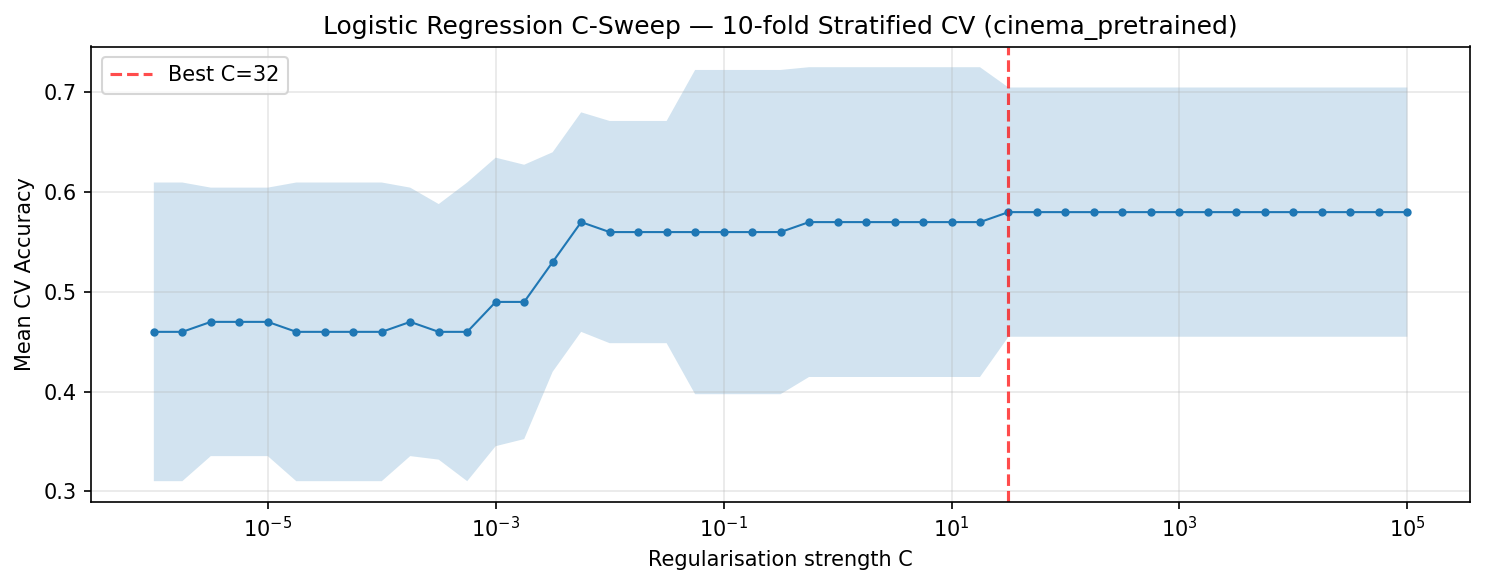

In [3]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=150)

x_values = [r["param_value"] for r in sweep]
mean_accs = [r["mean_cv_acc"] for r in sweep]
std_accs = [r["std_cv_acc"] for r in sweep]

ax.semilogx(x_values, mean_accs, "o-", markersize=3, linewidth=1)
ax.fill_between(
    x_values,
    [m - s for m, s in zip(mean_accs, std_accs)],
    [m + s for m, s in zip(mean_accs, std_accs)],
    alpha=0.2,
)
best_val = config["best_hyperparam"]
param_name = config["hyperparam_name"]
ax.axvline(best_val, color="red", linestyle="--", alpha=0.7, label=f"Best {param_name}={best_val:.2g}")

if EVAL_MODE == "logreg":
    ax.set_xlabel("Regularisation strength C")
    ax.set_title(f"Logistic Regression C-Sweep — 10-fold Stratified CV ({MODEL_NAME})")
else:
    ax.set_xlabel("Learning Rate")
    ax.set_title(f"Fine-Tune LR Sweep — 10-fold Stratified CV ({MODEL_NAME})")

ax.set_ylabel("Mean CV Accuracy")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Per-Class ROC Curves

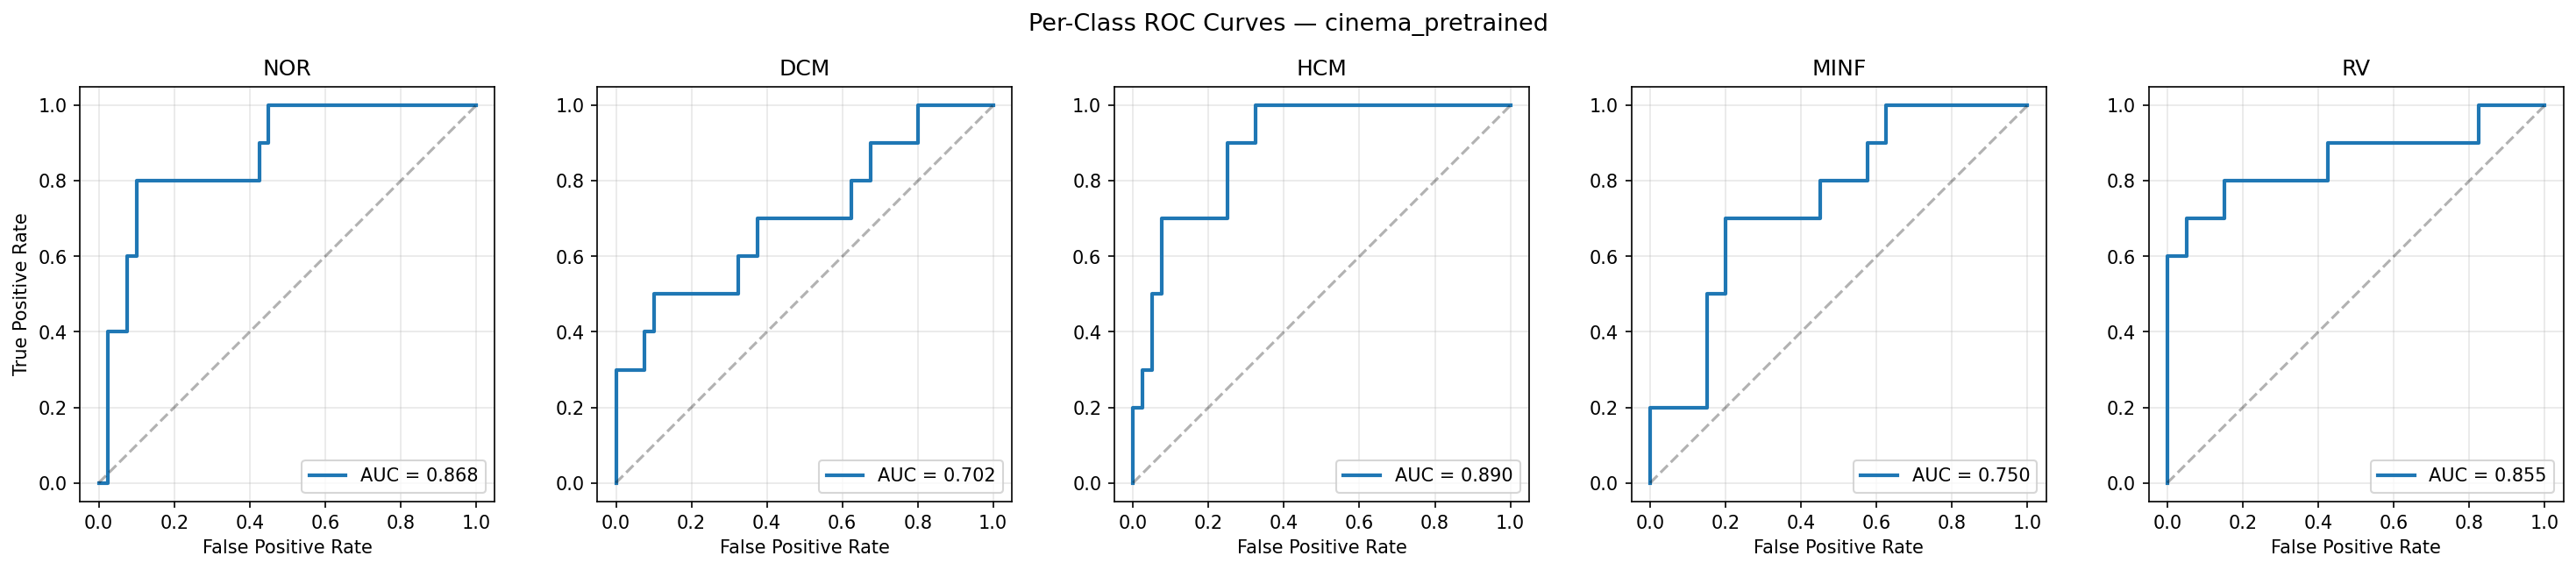

In [4]:
y_true_bin = label_binarize(five_way["true_labels"], classes=list(range(NUM_PATHOLOGIES)))
y_prob = np.array(five_way["probabilities"])

fig, axes = plt.subplots(1, NUM_PATHOLOGIES, figsize=(4 * NUM_PATHOLOGIES, 4), dpi=150)

for i, (cls_name, cls_idx) in enumerate(PATHOLOGY_CLASSES.items()):
    fpr, tpr, _ = sk_roc_curve(y_true_bin[:, cls_idx], y_prob[:, cls_idx])
    roc_auc_val = sk_auc(fpr, tpr)

    axes[i].plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc_val:.3f}")
    axes[i].plot([0, 1], [0, 1], "k--", alpha=0.3)
    axes[i].set_xlabel("False Positive Rate")
    if i == 0:
        axes[i].set_ylabel("True Positive Rate")
    axes[i].set_title(cls_name)
    axes[i].legend(loc="lower right")
    axes[i].set_aspect("equal")
    axes[i].grid(True, alpha=0.3)

fig.suptitle(f"Per-Class ROC Curves — {MODEL_NAME}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Per-Class AUC Bar Chart

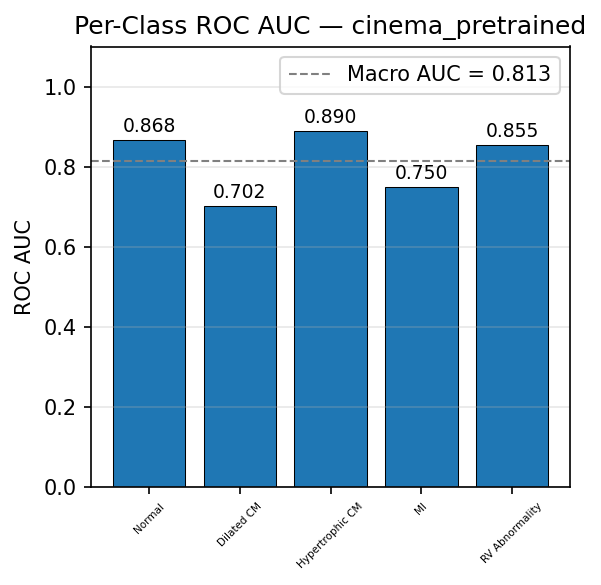

In [5]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=150)

class_names = [PATHOLOGY_NAMES_LONG[cls] for cls in PATHOLOGY_CLASSES.keys()]
per_class_auc = [roc["per_class_auc"][cls] for cls in PATHOLOGY_CLASSES.keys()]
macro_auc = roc["macro_auc"]

bars = ax.bar(class_names, per_class_auc, edgecolor="black", linewidth=0.5)
ax.axhline(macro_auc, color="gray", linestyle="--", linewidth=1, label=f"Macro AUC = {macro_auc:.3f}")

for bar, val in zip(bars, per_class_auc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("ROC AUC")
ax.set_title(f"Per-Class ROC AUC — {MODEL_NAME}")
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.xaxis.set_tick_params(rotation=45, labelsize=5)
plt.tight_layout()
plt.show()

## Confusion Matrix

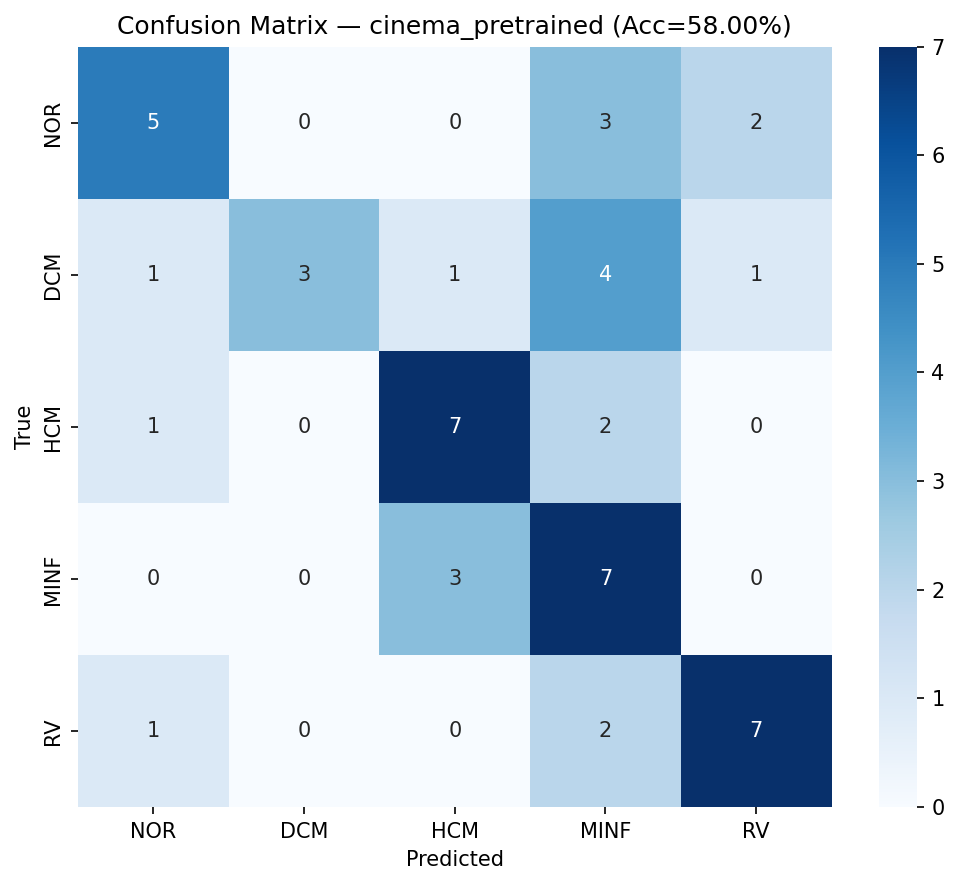

In [6]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=150)

class_names_short = list(PATHOLOGY_CLASSES.keys())
cm = np.array(five_way["confusion_matrix"])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names_short,
    yticklabels=class_names_short,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — {MODEL_NAME} (Acc={five_way['accuracy']:.2%})")
plt.tight_layout()
plt.show()

## Binary Disease Detection ROC

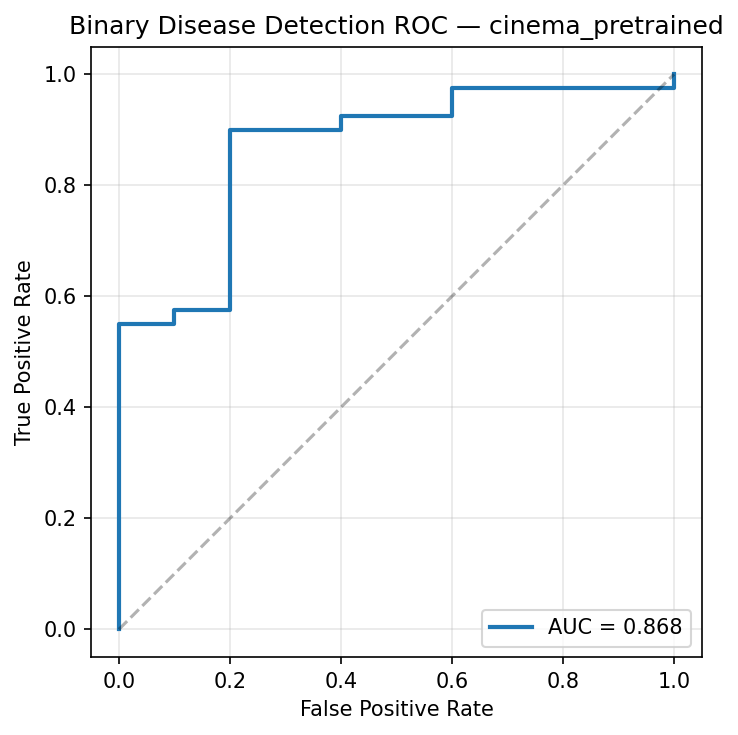

In [7]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=150)

fpr, tpr, _ = sk_roc_curve(binary["binary_labels"], binary["binary_probs"])
roc_auc_val = sk_auc(fpr, tpr)

ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc_val:.3f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"Binary Disease Detection ROC — {MODEL_NAME}")
ax.legend(loc="lower right")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary Table

In [8]:
import pandas as pd

report_df = pd.DataFrame(five_way["classification_report"]).T
display(report_df.round(3))

,precision,recall,f1-score,support
NOR,0.625,0.50,0.556,10.00
DCM,1.000,0.30,0.462,10.00
HCM,0.636,0.70,0.667,10.00
MINF,0.389,0.70,0.500,10.00
RV,0.700,0.70,0.700,10.00
accuracy,0.580,0.58,0.580,0.58
macro avg,0.670,0.58,0.577,50.00
weighted avg,0.670,0.58,0.577,50.00
